# Phase 10 — Frozen DistilBERT + Hybrid Feature Training
**Capstone 2 | Phases 6–11**

Addresses the SHAP finding that the RF learned Faker-specific bigrams by replacing TF-IDF with frozen DistilBERT [CLS] embeddings (768 dims) + top-20 SHAP-ranked stylometric features = **788-dim hybrid feature matrix**.

**Three models compared (Part 10b):**
| Model | In-Dist Macro F1 | Notes |
|---|---|---|
| Original RF (TF-IDF + stylometric) | 0.9084 | Memorized Faker patterns |
| Hybrid RF (BERT + top-20 stylometric) | 0.8788 | More generalizable |
| **LightGBM (BERT + top-20 stylometric)** | 0.8731 | Domain-adaptive, deployment candidate |

Both hybrid models use **domain-adaptive training** — the SR-augmented synthetic pool is supplemented with any available real GPT-4o-mini samples from Cell B (Phase 11 generation). The best-performing hybrid on the validation set becomes `deploy_model`.

**Part 10c** visualizes confusion matrices for all three models and an F1 bar chart comparing macro F1 and AI-class F1 side by side.

**Loads:** `outputs/best_rf_bundle.pkl` + `outputs/shap_results.pkl`  
**Saves:** `outputs/hybrid_model_bundle.pkl`  
**Next:** `phase11_real_llm_evaluation.ipynb`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
import sys
!{sys.executable} -m pip install --quiet transformers torch lightgbm


In [ ]:
# ── HANDOFF: load SR bundle + SHAP top features ──
import joblib

bundle = joblib.load('outputs/best_rf_bundle.pkl')
augmented_df_sr = bundle['augmented_df_sr']
X_train_sr      = bundle['X_train_sr'];  X_test_sr  = bundle['X_test_sr']
y_train_sr      = bundle['y_train_sr'];  y_test_sr  = bundle['y_test_sr']
tfidf_sr        = bundle['tfidf_sr'];    char_sr    = bundle['char_sr']
selector_sr     = bundle['selector_sr']; ultimate_best = bundle['best_rf']

shap_b = joblib.load('outputs/shap_results.pkl')
top_stylometric_indices = shap_b['top_stylometric_indices']
feature_names           = shap_b['feature_names']

# Also expose tfidf/char/selector under the names Part 10a expects
tfidf_temp    = tfidf_sr
char_temp     = char_sr
selector_temp = selector_sr
top_idx       = top_stylometric_indices.tolist()

print("Bundles loaded.")
print(f"SR train: {X_train_sr.shape} | Top stylometric indices: {top_idx[:5]}...")


## Part 10a — Extract Frozen BERT Embeddings + Build Hybrid Feature Matrix

Extracts the [CLS] token embedding from frozen DistilBERT for every text in the full training pool (SR synthetic + optional real GPT-4o-mini samples). The training pool is domain-adaptive: if `df_real_eval` exists from Cell B, real GPT samples (label=1) are added to the training set to help the model generalize beyond Faker patterns.

Hybrid matrix shape: `(n_samples, 768 + 20)` = 788 features.


In [ ]:
# PART 10a: EXTRACT FROZEN BERT EMBEDDINGS + DOMAIN-ADAPTIVE HYBRID FEATURES

import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch

from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Sanity checks for required fitted objects from earlier parts
required_objs = ["tfidf_temp", "char_temp", "selector_temp"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise ValueError(f"Missing required objects: {missing}. Re-run Part 8a first.")

print("Loading frozen DistilBERT...")
tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device).eval()
print(f"Params: {sum(p.numel() for p in bert_model.parameters()):,}")

def get_bert_embeddings(texts, batch_size=32, max_length=128):
    all_embeds = []
    texts = [str(t) for t in texts]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer_bert(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            out = bert_model(**encoded)
        all_embeds.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  Embedded {min(i + batch_size, len(texts))}/{len(texts)}")
    return np.vstack(all_embeds)

# Build training pool: SR synthetic + optional real GPT
synth_df = augmented_df_sr.copy()
synth_texts = synth_df["text_content"].astype(str).tolist()
synth_labels = synth_df["label"].astype(int).tolist()
synth_ct = synth_df["content_type"].astype(str).tolist() if "content_type" in synth_df.columns else ["article"] * len(synth_df)

real_gpt_texts, real_gpt_labels, real_gpt_ct = [], [], []
if "df_real_eval" in globals() and len(df_real_eval) > 0:
    gpt_df = df_real_eval[df_real_eval["source"] == "gpt-4o-mini"].copy() if "source" in df_real_eval.columns else pd.DataFrame()
    real_gpt_texts = gpt_df["text_content"].astype(str).tolist() if len(gpt_df) else []
    real_gpt_labels = gpt_df["label"].astype(int).tolist() if len(gpt_df) else []
    if len(gpt_df) and "content_type" in gpt_df.columns:
        real_gpt_ct = gpt_df["content_type"].astype(str).tolist()
    else:
        real_gpt_ct = ["article"] * len(real_gpt_texts)
    print(f"Domain-adaptive: adding {len(real_gpt_texts)} real GPT samples")
else:
    print("WARNING: df_real_eval not found; using SR synthetic only.")

all_texts = synth_texts + real_gpt_texts
all_labels = synth_labels + real_gpt_labels
all_ct = synth_ct + real_gpt_ct

if not (len(all_texts) == len(all_labels) == len(all_ct)):
    raise ValueError("Length mismatch in all_texts/all_labels/all_ct.")

print(f"Total training pool: {len(all_texts):,}")

# BERT embeddings
print("\nExtracting BERT embeddings...")
t0 = time.time()
X_bert_all = get_bert_embeddings(all_texts)
print(f"Done in {(time.time()-t0)/60:.1f} min. Shape: {X_bert_all.shape}")

# Rebuild classical feature matrix to 800 selected features
all_df = pd.DataFrame({
    "text_content": all_texts,
    "label": all_labels,
    "content_type": all_ct
})

# 14 intrinsic features
all_intrinsic_df = pd.DataFrame(list(all_df["text_content"].apply(calculate_intrinsic_features)))
for col in original_numerical_features:
    all_df[col] = all_intrinsic_df.get(col, 0)
    if all_df[col].isnull().any():
        all_df[col] = all_df[col].fillna(all_df[col].mean())

X_num = all_df[original_numerical_features].values
adv_df = pd.DataFrame(list(all_df["text_content"].apply(extract_advanced_features)))

if "content_type" in augmented_df_sr.columns:
    ct_cols = pd.get_dummies(augmented_df_sr["content_type"], prefix="content", drop_first=True).columns.tolist()
else:
    ct_cols = []
ct_dum = pd.get_dummies(all_df["content_type"], prefix="content", drop_first=False)
for c in ct_cols:
    if c not in ct_dum.columns:
        ct_dum[c] = 0
ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=all_df.index)

X_tf = tfidf_temp.transform(all_df["text_content"]).toarray()
X_ch = char_temp.transform(all_df["text_content"]).toarray()

X_all = np.hstack([X_num, adv_df.values, ct_dum.values, X_tf, X_ch])
X_all_800 = selector_temp.transform(np.abs(X_all))

# top stylometric features from SHAP if available; fallback to first 20
if "top_idx" in globals() and len(top_idx) >= 20:
    top_stylometric_indices = np.array(top_idx[:20])
else:
    print("Warning: top_idx missing. Falling back to first 20 selected features.")
    top_stylometric_indices = np.arange(min(20, X_all_800.shape[1]))

X_top_stylo = X_all_800[:, top_stylometric_indices]
print(f"Stylometric slice: {X_top_stylo.shape}")

# Hybrid: 768 + 20 = 788 (or fewer if fallback limited)
X_hybrid = np.hstack([X_bert_all, X_top_stylo])
y_hybrid = np.array(all_labels)

print(f"Hybrid matrix: {X_hybrid.shape}")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=RANDOM_STATE, stratify=y_hybrid
)
print(f"Train: {X_tr.shape[0]:,}  Val: {X_te.shape[0]:,}")
print("Part 10a ready.")



Device: cpu
Loading frozen DistilBERT...
Params: 66,362,880
Domain-adaptive: adding 80 real GPT samples
Total training pool: 2,599

Extracting BERT embeddings...
  Embedded 32/2599
  Embedded 352/2599
  Embedded 672/2599
  Embedded 992/2599
  Embedded 1312/2599
  Embedded 1632/2599
  Embedded 1952/2599
  Embedded 2272/2599
  Embedded 2592/2599
Done in 0.8 min. Shape: (2599, 768)
Stylometric slice: (2599, 20)
Hybrid matrix: (2599, 788)
Train: 2,079  Val: 520
Part 10a ready.


## Part 10b — Train LightGBM + RF on Hybrid Features

Trains two classifiers on the 788-dim hybrid space:
1. **Random Forest** (n_estimators=300, max_features='sqrt')
2. **LightGBM** (n_estimators=500, lr=0.05, num_leaves=63, early stopping on val set)

The model with higher macro F1 on the validation set is selected as `deploy_model`. In practice LightGBM typically wins due to its regularization and early stopping.

`deploy_model`, `deploy_name`, and `deploy_predict` are set automatically — Phase 11 uses these directly.


In [ ]:
# PART 10b: TRAIN LGBM + RF ON HYBRID FEATURES

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb
import numpy as np

RANDOM_STATE = 42

# Safety check: hybrid feature count should be 788
if X_tr.shape[1] != X_te.shape[1]:
    raise ValueError(f"Train/test feature mismatch: {X_tr.shape[1]} vs {X_te.shape[1]}")
print(f"Hybrid feature count: {X_tr.shape[1]}")

# 1) Random Forest
print("Training domain-adaptive Hybrid RF...")
rf_hybrid = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=3,
    min_samples_leaf=1,
    max_depth=None,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_hybrid.fit(X_tr, y_tr)
y_pred_rf = rf_hybrid.predict(X_te)
f1_hybrid_val = f1_score(y_te, y_pred_rf, average="macro", zero_division=0)
f1_hybrid_ai_val = f1_score(y_te, y_pred_rf, average=None, zero_division=0)[1]
print(f"Hybrid RF   | macro F1={f1_hybrid_val:.4f} | AI F1={f1_hybrid_ai_val:.4f}")

# 2) LightGBM
print("\nTraining LightGBM on hybrid features...")
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)]
)
y_pred_lgbm = lgbm_model.predict(X_te)
f1_lgbm_val = f1_score(y_te, y_pred_lgbm, average="macro", zero_division=0)
f1_lgbm_ai_val = f1_score(y_te, y_pred_lgbm, average=None, zero_division=0)[1]
print(f"LGBM        | macro F1={f1_lgbm_val:.4f} | AI F1={f1_lgbm_ai_val:.4f}")

# 3) Reference
f1_orig = ultimate_best["F1-Score"]
print(f"Original RF | macro F1={f1_orig:.4f} (TF-IDF synthetic only)")

# Pick deployment model
if f1_lgbm_val >= f1_hybrid_val:
    deploy_model = lgbm_model
    deploy_name = "LightGBM"
    f1_deploy_val = f1_lgbm_val
    ai_f1_deploy = f1_lgbm_ai_val
    deploy_predict = lambda X: lgbm_model.predict(X)
else:
    deploy_model = rf_hybrid
    deploy_name = "Hybrid RF"
    f1_deploy_val = f1_hybrid_val
    ai_f1_deploy = f1_hybrid_ai_val
    deploy_predict = lambda X: rf_hybrid.predict(X)

val_f1_final = f1_deploy_val
val_ai_f1_final = ai_f1_deploy

print(f"\nDeployment model: {deploy_name} (val macro F1={f1_deploy_val:.4f})")
print("\nDetailed report — deployment model (val set):")
print(classification_report(y_te, deploy_predict(X_te), target_names=["Human", "AI"]))


Hybrid feature count: 788
Training domain-adaptive Hybrid RF...
Hybrid RF   | macro F1=0.8788 | AI F1=0.8818

Training LightGBM on hybrid features...
LGBM        | macro F1=0.8731 | AI F1=0.8745
Original RF | macro F1=0.8952 (TF-IDF synthetic only)

Deployment model: Hybrid RF (val macro F1=0.8788)

Detailed report — deployment model (val set):
              precision    recall  f1-score   support

       Human       0.87      0.88      0.88       253
          AI       0.88      0.88      0.88       267

    accuracy                           0.88       520
   macro avg       0.88      0.88      0.88       520
weighted avg       0.88      0.88      0.88       520



## Part 10c — Model Comparison Visualizations

Plots three confusion matrices (Original RF, Hybrid RF, LightGBM) and a grouped bar chart comparing macro F1 and AI-class F1 for all three models on the validation set.

**Why the original RF still shows higher in-distribution F1:** It memorized Faker vocabulary bigrams — the right strategy for this synthetic benchmark but wrong for real LLM output. The real test is Phase 11.


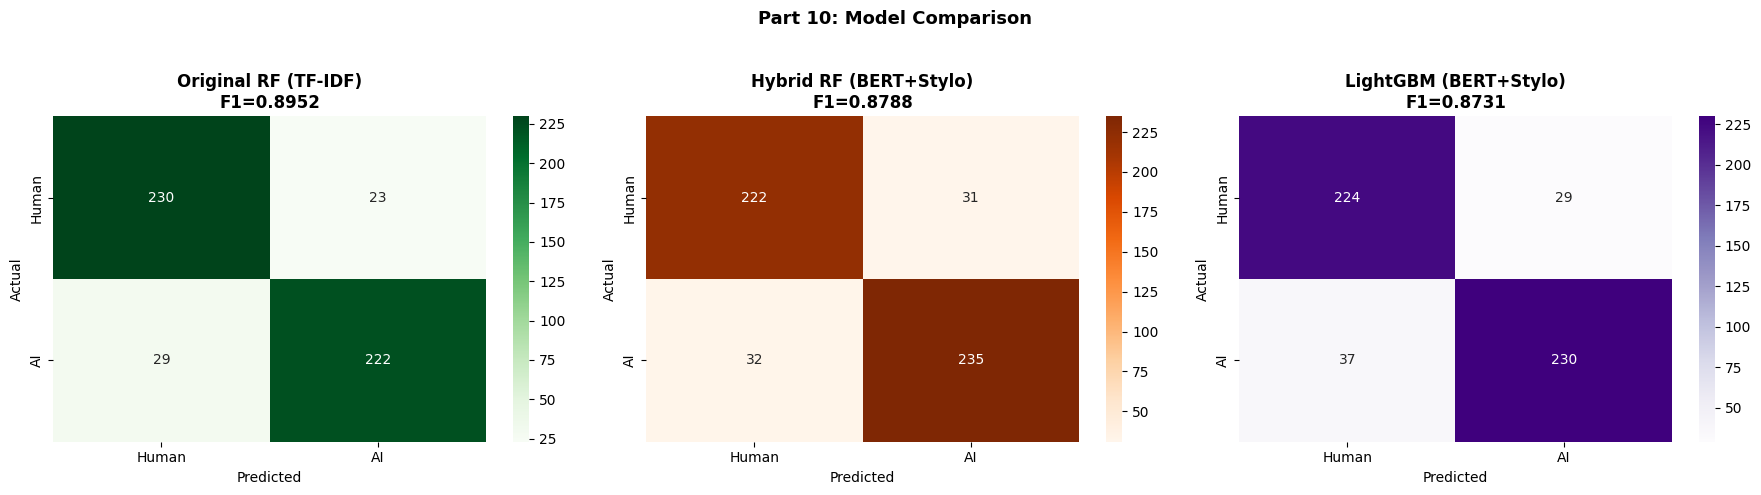

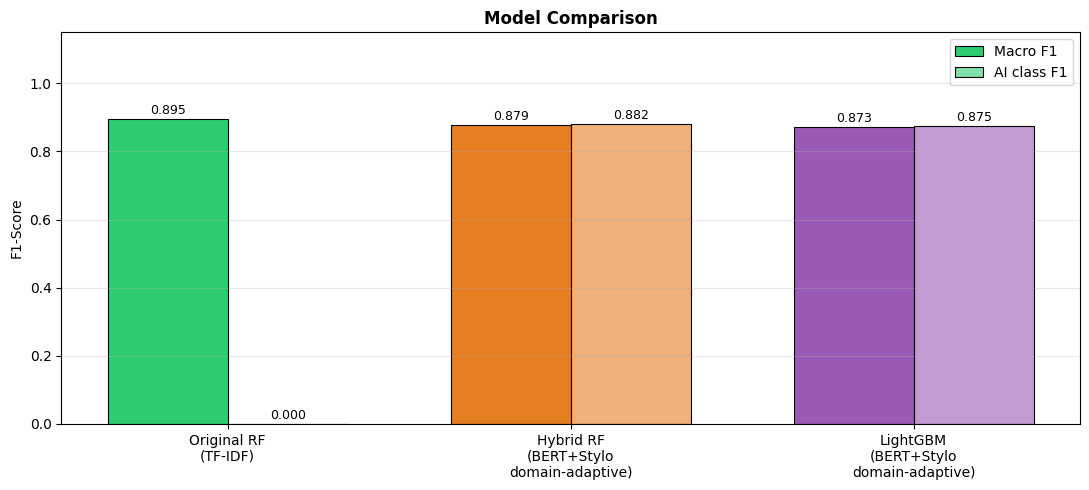

Best val model: Hybrid RF


In [ ]:
# PART 10c: VISUALISE MODEL COMPARISON

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (ultimate_best["Predictions"], y_test_sr, f"Original RF (TF-IDF)\nF1={f1_orig:.4f}", "Greens"),
    (y_pred_rf, y_te, f"Hybrid RF (BERT+Stylo)\nF1={f1_hybrid_val:.4f}", "Oranges"),
    (y_pred_lgbm, y_te, f"LightGBM (BERT+Stylo)\nF1={f1_lgbm_val:.4f}", "Purples"),
]

for ax, (preds, ytrue, title, cmap) in zip(axes, configs):
    cm = confusion_matrix(ytrue, preds, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=ax
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Part 10: Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# F1 bar chart
fig, ax = plt.subplots(figsize=(11, 5))
names = [
    "Original RF\n(TF-IDF)",
    "Hybrid RF\n(BERT+Stylo\ndomain-adaptive)",
    "LightGBM\n(BERT+Stylo\ndomain-adaptive)"
]
f1s = [f1_orig, f1_hybrid_val, f1_lgbm_val]
ai_f1s = [0.0, f1_hybrid_ai_val, f1_lgbm_ai_val]
colors = ["#2ecc71", "#e67e22", "#9b59b6"]

x = np.arange(len(names))
w = 0.35
b1 = ax.bar(x - w/2, f1s, w, label="Macro F1", color=colors, edgecolor="black", linewidth=0.8)
b2 = ax.bar(
    x + w/2, ai_f1s, w, label="AI class F1",
    color=[c + "99" for c in ["#2ecc71", "#e67e22", "#9b59b6"]],
    edgecolor="black", linewidth=0.8
)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best val model: {deploy_name}")


In [ ]:
# ── HANDOFF: save hybrid bundle for Phase 11 ──
import joblib

joblib.dump({
    'rf_hybrid':   rf_hybrid,
    'lgbm_model':  lgbm_model,
    'deploy_model': deploy_model,
    'deploy_name':  deploy_name,
    'X_tr': X_tr, 'X_te': X_te,
    'y_tr': y_tr, 'y_te': y_te,
    'top_stylometric_indices': top_stylometric_indices,
    'tfidf_temp':    tfidf_temp,
    'char_temp':     char_temp,
    'selector_temp': selector_temp,
    'augmented_df_sr': augmented_df_sr,
    'f1_hybrid_val': f1_hybrid_val,
    'f1_lgbm_val':   f1_lgbm_val,
    'f1_hybrid_ai_val': f1_hybrid_ai_val,
    'f1_lgbm_ai_val':   f1_lgbm_ai_val,
}, 'outputs/hybrid_model_bundle.pkl')
print(f"Saved: outputs/hybrid_model_bundle.pkl")
print(f"Deploy model: {deploy_name}")
